# Training
Aqui solo entrenamos lo que es la positividad, debido a su facilidad para calcular datos

In [1]:
# Robust loader handling both old "batch" and "flattened" merged formats

import glob
import pickle
import pandas as pd

files = sorted(glob.glob("data_batches/merged_*.pkl")) # + glob.glob("data_batches/batch_*.pkl")

rows = []
for fp in files:
    with open(fp, "rb") as f:
        data = pickle.load(f)
    
    # Data may be:
    # 1) A dict with "params" (N×7 array) and "results" (list of dicts)
    # 2) A list whose elements are either:
    #    a) batch-dicts with "params"/"results" (old-merged)
    #    b) single-point dicts with "params" (length-7 array) and "result"/"results" (dict)
    
    # Helper to flatten a batch-dict
    def flatten_batch(batch):
        ps = batch["params"]
        rs = batch["results"]
        for p, r in zip(ps, rs):
            yield p, r
    
    # Helper to flatten a single-point dict
    def flatten_point(entry):
        p = entry["params"]
        # entry may use "result" or "results"
        r = entry.get("result", entry.get("results"))
        if isinstance(r, list):  # sometimes "results" is a list of 1 dict
            r = r[0]
        yield p, r
    
    # Now dispatch
    if isinstance(data, dict) and "params" in data and "results" in data:
        # Single batch file
        for p, r in flatten_batch(data):
            row = {
                "m_A":      p[0],
                "m_phi":    p[1],
                "sin_ba":   p[2],
                "tan_beta": p[3],
                "lambda_6": p[4],
                "lambda_7": p[5],
                "m12_2":    p[6],
                **r
            }
            rows.append(row)
    
    elif isinstance(data, list):
        # Merged file: list of entries
        for entry in data:
            if isinstance(entry, dict):
                if "params" in entry and "results" in entry:
                    # This entry is a full batch
                    for p, r in flatten_batch(entry):
                        row = {
                            "m_A":      p[0],
                            "m_phi":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                elif "params" in entry:
                    # Single-point entry
                    for p, r in flatten_point(entry):
                        row = {
                            "m_A":      p[0],
                            "m_phi":    p[1],
                            "sin_ba":   p[2],
                            "tan_beta": p[3],
                            "lambda_6": p[4],
                            "lambda_7": p[5],
                            "m12_2":    p[6],
                            **r
                        }
                        rows.append(row)
                else:
                    raise ValueError(f"Unexpected dict keys in entry from {fp}: {entry.keys()}")
            else:
                raise ValueError(f"Unexpected entry type in merged list from {fp}: {type(entry)}")
    else:
        raise ValueError(f"Unknown data structure in file {fp}: {type(data)}")

# 3) Build DataFrame and save to Parquet (or fallback to CSV)
df = pd.DataFrame(rows)

In [6]:
(df["positivity_ok"] == 1).sum()

300981

In [8]:
df.dropna(inplace=True)

LogReg best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
LogReg test ROC–AUC: 0.994
RF best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
RF test ROC–AUC: 1.000


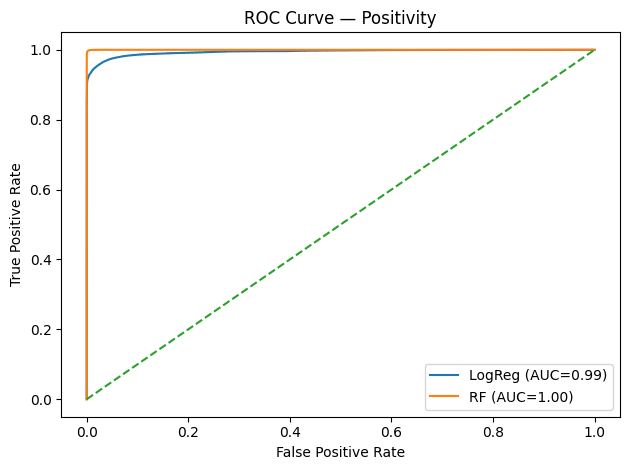

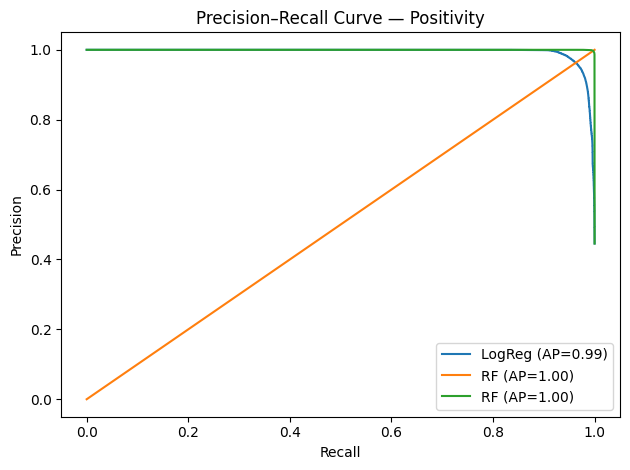

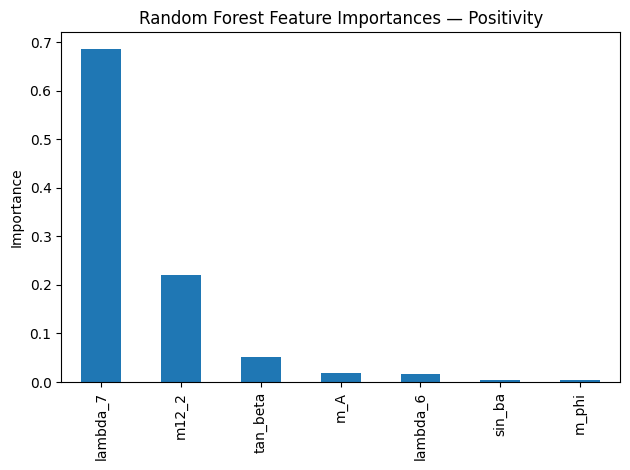

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# — assume df is already loaded —

# 1) Prepare features and target (positivity_ok)
features = ["m_A", "m_phi", "m12_2", "tan_beta", "sin_ba", "lambda_6", "lambda_7"]
X = df[features]
y = df["positivity_ok"]

# 2) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Scale features for Logistic Regression
scaler = StandardScaler().fit(X_train)
X_tr_scaled = scaler.transform(X_train)
X_te_scaled = scaler.transform(X_test)

# 4) Logistic Regression + GridSearchCV
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_lr.fit(X_tr_scaled, y_train)
best_lr = grid_lr.best_estimator_

# Evaluate LR
y_proba_lr = best_lr.predict_proba(X_te_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, y_proba_lr)
print("LogReg best params:", grid_lr.best_params_)
print(f"LogReg test ROC–AUC: {lr_auc:.3f}")

# 5) Random Forest + GridSearchCV
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)  # RF handles unscaled data
best_rf = grid_rf.best_estimator_

# Evaluate RF
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, y_proba_rf)
print("RF best params:", grid_rf.best_params_)
print(f"RF test ROC–AUC: {rf_auc:.3f}")

# —========== PLOTS ==========—

# ROC Curve
plt.figure()
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={lr_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={rf_auc:.2f})")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Positivity")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall Curve
plt.figure()
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)
plt.plot(rec_lr, prec_lr, label=f"LogReg (AP={ap_lr:.2f})")
plt.plot(rec_rf, rec_rf if False else rec_rf, label=f"RF (AP={ap_rf:.2f})")  # Correction below
plt.plot(rec_rf, prec_rf, label=f"RF (AP={ap_rf:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Positivity")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importances (RF)
importances = pd.Series(best_rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)
plt.figure()
importances.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances — Positivity")
plt.tight_layout()
plt.show()

